In [1]:
!pip install tensorflow tensorflow-hub tensorflow-datasets

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_datasets as tfds

from sklearn import metrics
from mlxtend.plotting import plot_confusion_matrix

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [3]:
train_data, validation_data, test_data = tfds.load(
    name='imdb_reviews',
    split=('train[:60%]', 'train[60%:]', 'test'),
    as_supervised=True
)

In [4]:
train_data, validation_data, test_data = tfds.load(
    name='imdb_reviews',
    split=('train[:60%]', 'train[60%:]', 'test'),
    as_supervised=True
)

In [5]:
train_examples_batch, train_labels_batch = next(iter(train_data.batch(10)))
train_labels_batch

<tf.Tensor: shape=(10,), dtype=int64, numpy=array([0, 0, 0, 1, 1, 1, 0, 0, 0, 0], dtype=int64)>

In [6]:
import tensorflow as tf
import tensorflow_hub as hub

embedding = "https://tfhub.dev/google/nnlm-en-dim128-with-normalization/2"

# Create custom wrapper
class HubLayer(tf.keras.layers.Layer):
    def __init__(self, url):
        super().__init__()
        self.hub_layer = hub.KerasLayer(url, trainable=True)
        
    def call(self, inputs):
        return self.hub_layer(inputs)
        
# Build model
inputs = tf.keras.Input(shape=(), dtype=tf.string)

x = HubLayer(embedding)(inputs) # ✅ wrapped layer
x = tf.keras.layers.Dense(32, activation='relu')(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)
outputs = tf.keras.layers.Dense(1)(x)

model = tf.keras.Model(inputs, outputs)

In [7]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None)                      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hub_layer (HubLayer)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,673 (18.25 KB)

 Trainable params: 4,673 (18.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
optimizer='adam',
loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_data.shuffle(10000).batch(512),
    epochs=5,
    validation_data=validation_data.batch(512),
    verbose=1
)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.5181 - loss: 0.6628 - val_accuracy: 0.5660 - val_loss: 0.6191
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6668 - loss: 0.5736 - val_accuracy: 0.7238 - val_loss: 0.5291
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7439 - loss: 0.4949 - val_accuracy: 0.7521 - val_loss: 0.4699
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.7825 - loss: 0.4505 - val_accuracy: 0.7891 - val_loss: 0.4390
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7953 - loss: 0.4267 - val_accuracy: 0.8026 - val_loss: 0.4231


In [10]:
results = model.evaluate(test_data.batch(512), verbose=2)

for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.3f}")

49/49 - 1s - 28ms/step - accuracy: 0.7966 - loss: 0.4303
loss: 0.430
compile_metrics: 0.797


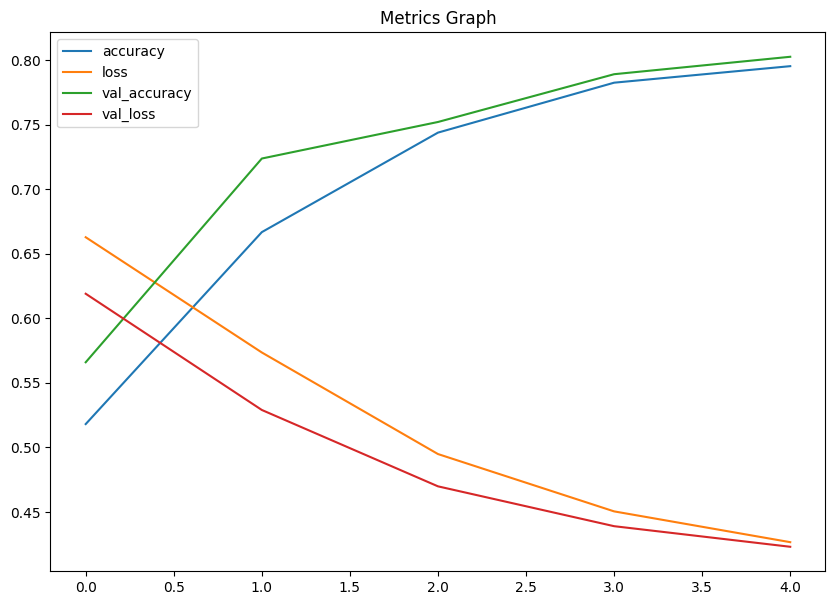

In [11]:
pd.DataFrame(history.history).plot(figsize=(10,7))
plt.title("Metrics Graph")
plt.show()

In [12]:
texts = []
true_labels = []

for text, label in test_data:
    texts.append(text.numpy().decode('utf-8')) # convert bytes → string
    true_labels.append(label.numpy())
    
# Convert labels only (texts will be converted later)
true_labels = np.array(true_labels)

In [13]:
texts_tensor = tf.constant(texts)

predicted_probs = model.predict(texts_tensor)
predicted_labels = (predicted_probs > 0).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [14]:
report = metrics.classification_report(
    true_labels,
    predicted_labels,
    target_names=['Negative', 'Positive']
)

print(report)

              precision    recall  f1-score   support

    Negative       0.80      0.80      0.80     12500
    Positive       0.80      0.80      0.80     12500

    accuracy                           0.80     25000
   macro avg       0.80      0.80      0.80     25000
weighted avg       0.80      0.80      0.80     25000



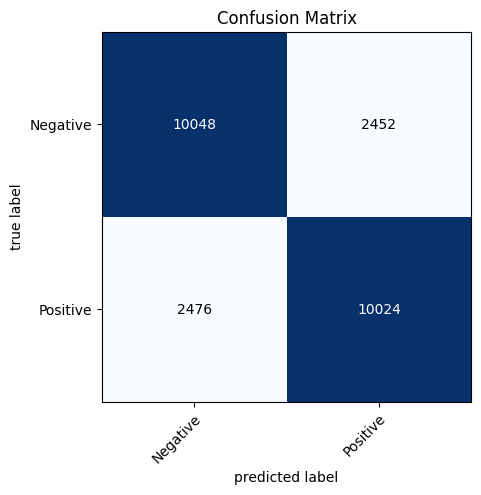

In [15]:
cm = metrics.confusion_matrix(true_labels, predicted_labels)

plot_confusion_matrix(cm, class_names=['Negative', 'Positive'])
plt.title("Confusion Matrix")
plt.show()
